# Template Clustering Text
CSV -> bersihin teks -> TF-IDF -> KMeans -> evaluasi -> plot -> insight


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv("D:/Tugas Kuliah/Tugas Kuliah Sem 5/Data Mining II/UTS/Data Latihan UTS Datmin/Text/Data Latihan Datmin II (Text).csv")                        # GANTI nama file
df = df.rename(columns={"content": "corpus"})  # GANTI nama kolom teks
df = df.sample(5000, random_state=42)   # kalau datanya gede, ambil sampel acak
df = df.dropna(subset="corpus").drop_duplicates(subset="corpus").reset_index(drop=True)
print(df.shape)
df.head()


(5000, 12)


,index,reviewId,userName,userImage,corpus,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,75721,0319b8e0-277f-5fa7-ba13-e205f18b8d7e,Pengguna Sintetis 075722,NaN,Untuk pertama kalinya saya memakai fitur ini. ...,5,0,6.23.0,2024-07-12 15:01:33,Terima kasih atas ulasan Anda. Semoga layanan ...,2024-07-14 04:46:33,6.23.0
1,80184,346ef725-d0ef-517a-963b-cc21c22b68ef,Pengguna Sintetis 080185,NaN,Untuk pertama kalinya saya memakai fitur ini. ...,5,0,6.26.2,2025-09-06 03:11:29,NaN,NaN,6.26.2
2,19864,0b5d04d3-e279-512f-b57c-d9f1f4f04ea9,Pengguna Sintetis 019865,NaN,"Selama memakai aplikasi BSI, Panduan dari laya...",1,0,6.22.0,2024-11-30 22:28:33,NaN,NaN,6.22.0
3,76699,f7649a93-5e98-5f1a-b619-181864817853,Pengguna Sintetis 076700,NaN,Pengiriman uang lewat bi fast cukup membantu t...,3,0,6.24.0,2024-10-22 17:45:54,NaN,NaN,6.24.0
4,92991,b0adc48b-3d6c-5527-9523-b68fbbe4ff7b,Pengguna Sintetis 092992,NaN,Pembayaran tagihan internet rumah kurang nyama...,2,18,6.26.2,2024-10-01 09:06:34,NaN,NaN,6.26.2


## Load data alternatif: ZIP berisi TXT


In [ ]:
## Alternatif load ZIP berisi TXT: satu file TXT = satu dokumen.
## Tetap jalankan import pandas di atas; nonaktifkan bagian load CSV saat memakai ini.
## Hapus satu tanda # di awal setiap baris untuk mengaktifkan cell.
# from zipfile import ZipFile
#
# with ZipFile("data_text.zip") as z:  # GANTI path ZIP
#     files = sorted(n for n in z.namelist() if n.lower().endswith(".txt") and not n.endswith("/"))
#     df = pd.DataFrame({
#         "nama_file": files,
#         "corpus": [z.read(n).decode("utf-8-sig") for n in files]  # GANTI encoding jika perlu
#     })
#
# # df = df.sample(n=min(5000, len(df)), random_state=42)  # OPSIONAL: ubah 5000
# df = df.dropna(subset="corpus").drop_duplicates(subset="corpus").reset_index(drop=True)
# print(df.shape)
# df.head()


## Plot deskriptif


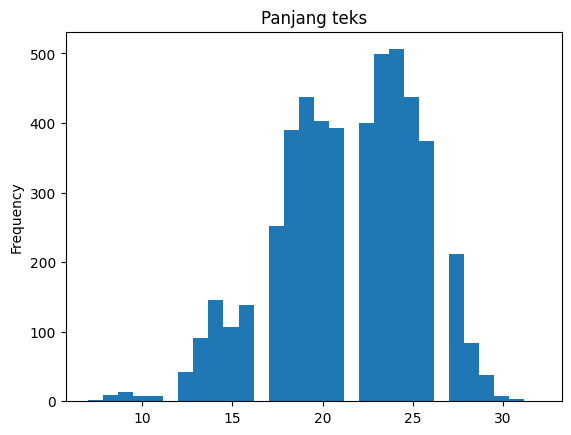

In [68]:
df["jumlah_kata"] = df["corpus"].str.split().str.len()
df["jumlah_kata"].plot(kind="hist", bins=30, title="Panjang teks")
plt.show()

# kalau ada kolom kategori
# df["kategori"].value_counts().plot(kind="bar")
# plt.show()


## Preprocessing


In [69]:
# Kalau belum terpasang, jalankan sekali:
# %pip install Sastrawi

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Stemmer bahasa Indonesia
stemmer = StemmerFactory().create_stemmer()
stop = set(stopwords.words("indonesian"))   # GANTI "english" kalau bahasa inggris
stop.update(["yg", "ga", "gak", "aja", "banget", "nya"])

def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if w not in stop]
    text = " ".join(words)
    text = stemmer.stem(text)  # STEMMING; beri # untuk menonaktifkan
    return text

df["cleaned"] = df["corpus"].apply(clean)

# Hapus teks yang kosong setelah cleaning dan stemming
df = df[df["cleaned"].str.strip().ne("")].reset_index(drop=True)
print("Jumlah data setelah cleaning:", len(df))
df[["corpus", "cleaned"]].head()


Jumlah data setelah cleaning: 5000


,corpus,cleaned
0,Untuk pertama kalinya saya memakai fitur ini. ...,kali pakai fitur selesai lapor customer servic...
1,Untuk pertama kalinya saya memakai fitur ini. ...,kali pakai fitur proses adu transaksi bantu bu...
2,"Selama memakai aplikasi BSI, Panduan dari laya...",pakai aplikasi bsi pandu layan langgan buruk b...
3,Pengiriman uang lewat bi fast cukup membantu t...,kirim uang bi fast bantu konsisten versi pasan...
4,Pembayaran tagihan internet rumah kurang nyama...,bayar tagih internet rumah nyaman ulang versi ...


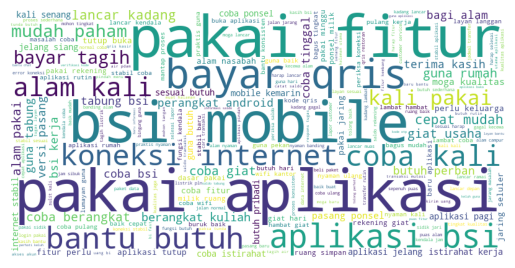

In [70]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(df["cleaned"]))
plt.imshow(wc)
plt.axis("off")
plt.show()


## TF-IDF


In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=5, max_df=0.95)
X_tfidf = vectorizer.fit_transform(df["cleaned"])   # dipakai lagi buat top keywords
X = X_tfidf

X.shape


(5000, 209)

## Tentukan k


  0%|          | 0/9 [00:00<?, ?it/s]

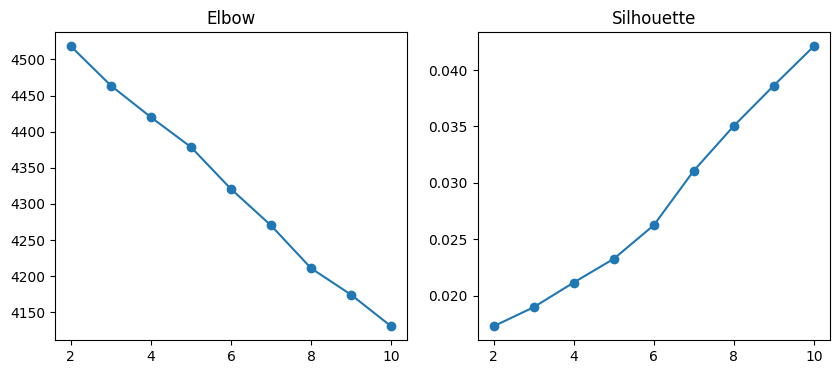

In [72]:
from tqdm.auto import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

ks = range(2, 11)
inertia, sil = [], []
for k in tqdm(ks):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow")
ax[1].plot(ks, sil, "o-"); ax[1].set_title("Silhouette")
plt.show()


k dipilih = ... karena ... (isi sendiri dari grafik)

## KMeans + evaluasi


In [73]:
k = 8   # GANTI
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
df["cluster"] = kmeans.labels_

print("Silhouette    :", silhouette_score(X, df["cluster"]))
print("Davies-Bouldin:", davies_bouldin_score(X.toarray(), df["cluster"]))
# kalau pakai SVD: ganti X.toarray() jadi X
# print("Davies-Bouldin:", davies_bouldin_score(X, df["cluster"]))
print(df["cluster"].value_counts())


Silhouette    : 0.035045716496085434
Davies-Bouldin: 4.854582389113232
cluster
2    1762
3     802
1     707
5     487
7     397
4     324
6     267
0     254
Name: count, dtype: int64


## Plot cluster (PCA)


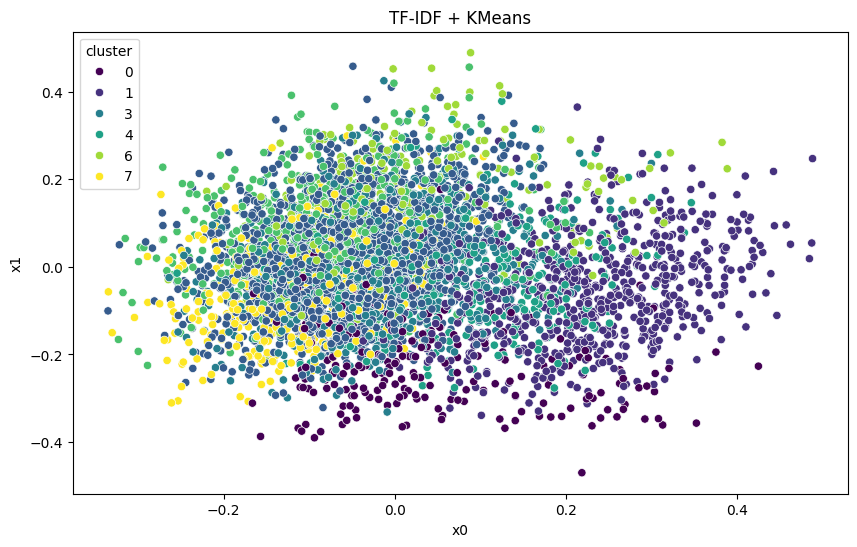

In [74]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X.toarray())
# kalau pakai SVD: pc = pca.fit_transform(X)
df["x0"], df["x1"] = pc[:, 0], pc[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="x0", y="x1", hue="cluster", palette="viridis")
plt.title("TF-IDF + KMeans")
plt.show()


## Insight tiap cluster


In [76]:
terms = vectorizer.get_feature_names_out()

for c in sorted(df["cluster"].unique()):
    mask = df["cluster"].eq(c).to_numpy()
    bagian = df.loc[mask]
    rata = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    kata_kunci = terms[np.argsort(rata)[::-1][:10]]

    print(f"\nCluster {c}: {len(bagian)} dokumen ({len(bagian) / len(df):.1%})")
    print("Kata kunci:", ", ".join(kata_kunci))
    print("Contoh teks:")
    for teks in bagian["corpus"].sample(n=min(2, len(bagian)), random_state=42):
        print(" -", teks)

# Kalau ada kolom label:
# pd.crosstab(df["cluster"], df["kategori"])



Cluster 0: 254 dokumen (5.1%)
Kata kunci: kadang, lancar, gagal, lambat, coba, aplikasi, pakai, guna, bsi, bayar
Contoh teks:
 - Respons petugas layanan pelanggan kurang lancar dan kadang gagal. Masih banyak yang perlu dibenahi.
 - Untuk pertama kalinya saya memakai fitur ini. Penyelesaian laporan oleh customer service kadang lancar kadang agak lambat. Saya memakai fitur ini untuk keperluan keluarga. Untuk sekarang cukup sesuai kebutuhan.

Cluster 1: 707 dokumen (14.1%)
Kata kunci: bayar, qris, tagih, coba, alam, pakai, restoran, butuh, guna, kali
Contoh teks:
 - Pembayaran iuran bpjs cukup stabil setelah pembaruan terakhir. Saya memakai fitur ini setiap beberapa hari.
 - Pembayaran tagihan listrik pln praktis untuk penggunaan sehari hari. Saya sudah memeriksa koneksi internet. Saya cukup puas dengan fitur ini.

Cluster 2: 1762 dokumen (35.2%)
Kata kunci: coba, aplikasi, pakai, alam, guna, bsi, butuh, kali, transaksi, akun
Contoh teks:
 - Untuk kebutuhan perbankan saya, Tampilan aplik